# Data Quality Report

Can you guess what we mean by Data Quality Report (DQR)?  Did you say it's a report of the quality of your data?  Nicely done.

This section will advance what we learned from the previous general step of simply understanding our data, to now being intentional about actually looking for issues.  Some of these are things you will always want to check regardless of the type of data or project, however some of your issues will be related to the idiosyncrasies of your data at hand and you'll have to be diligent catching them on your own.

````{margin}
```{note}
**Data Quality Reports (DQR)** are summaries and various aggregations of your data, which reveal basic understandings of your data for categorical counts, frequencies, and cardinalities, and numeric statistical moments and distributions, as well as data integrity issues such as missing values.
```
````

**Data Quality Reports** really are as simple as they sound.  They are essentially summaries and various levels of aggregations of your data - counts, frequencies, cardinalities, statistical moments, and some well known potential data integrity issues like missing values.  Don't worry if some of these terms or ideas are new to you.  We'll discuss them in turn below.

At this stage we're going to dig a little deeper than we have to get a sense for anything serious or any issuess that might need to be addressed either now, or potentially later on.  The main areas we'll want to focus on as we're building this concept of a DQR, are listed below.  These will allow us to see if the data is going to be smooth sailing or if it's likely to give us some trouble.

1. Feature Data Types
2. Feature Summaries
3. Data Integrity

In most cases, we will defer resolving any issues until we get to the Data Wranging and {doc}`preprocessing` steps.  There's a ton of overlap between the EDA, Data Wrangling, and Feature Engineering steps in the real world and you could address issues whenever it makes sense for your workflow.  For the sake of clarity, we'll continue to keep EDA about investigating and understanding, while preserving Data Wrangling to focus on making actual updates and changes to the data. 

For this step we'll again continue using the Sleep Study dataset from the previous sections to motivate our discussion.  Below see the abbreviated dataframe.

In [12]:
import pandas as pd
import numpy as np

# Read in the data from github repository
url = 'https://github.com/bradybr/practical-data-science-and-ml/blob/main/datasets/sleep_study.csv?raw=true'
dat = pd.read_csv(url, sep = ',')
dat

,id,gender,age,country,study_begin,study_end,active_mins,sleep_disturb_mins,sleep_rem_mins
0,1,F,38.0,USA,4/3/2021,4/9/2023,96.8,227.5,25.9
1,2,M,72.0,Poland,4/3/2021,4/9/2023,245.6,644.2,86.7
2,3,F,95.0,Italy,4/3/2021,4/9/2023,279.4,465.6,31.8
3,4,M,37.0,USA,4/3/2021,4/9/2023,60.0,109.0,19.7
4,5,F,80.0,Spain,4/3/2021,4/9/2023,89.4,113.3,38.6
...,...,...,...,...,...,...,...,...,...
872,872,F,17.0,Italy,4/3/2021,4/9/2023,42.1,87.7,42.3
873,873,F,64.0,USA,4/3/2021,4/9/2023,128.5,268.8,23.4
874,874,F,27.0,Italy,4/3/2021,4/9/2023,43.2,84.1,18.0
875,875,F,69.0,Spain,4/3/2021,4/9/2023,246.8,237.6,44.1


**<h3>Feature Summaries</h3>**

Kicking things off, recall the previous {doc}`data_types` section where we discussed the different formats and data types a variable could be represented as.  Different types of features are summarized in different ways as you'll see, and if your data types are inccorect, then you summaries will be inaccurate or missing key pieces of information.

At the heart of your Data Quality Report, are simple summaries of your data.  Counts, frequencies, cardinalities, statistical moments, and some well known potential data integrity issues like missing values.  Again, we'll explain what these terms mean shortly in case you're unfamiliar, but understand that it's entirely driven first and foremost by feature data types.  

```{tip}
Before we begin any real analysis of our data, the first thing we always want to check are the variable data types.  Your data and feature summaries will be inaccurate if this step is skipped.
```

So before we do much of anything else, we always want to look at data summaries for the data types of our features.  After our general data understanding is behind us, addressing data types is always step 2.  Recall from our {doc}`data_understanding` section, that we have a couple of standard questions we always ask about our features right away.  

>_Do you have all of the features (variables) you expect to have?_<br>
>_Do the features (variables) have the correct data types (numeric, string, date, etc.)?_

We already know we have all of the variables we expected, but what about if we have the correct _data types_ or not?

To answer this question, let's look at the data again by printing out the first few rows, plus the feature data types.  Remember, no matter the analytics platform you're using, there will be some way to either print out or view and update this information.

In [46]:
dat[0:3]

,id,gender,age,country,study_begin,study_end,active_mins,sleep_disturb_mins,sleep_rem_mins
0,1,F,38.0,USA,4/3/2021,4/9/2023,96.8,227.5,25.9
1,2,M,72.0,Poland,4/3/2021,4/9/2023,245.6,644.2,86.7
2,3,F,95.0,Italy,4/3/2021,4/9/2023,279.4,465.6,31.8


In [47]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877 entries, 0 to 876
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  877 non-null    int64  
 1   gender              877 non-null    object 
 2   age                 876 non-null    float64
 3   country             877 non-null    object 
 4   study_begin         877 non-null    object 
 5   study_end           864 non-null    object 
 6   active_mins         873 non-null    float64
 7   sleep_disturb_mins  871 non-null    float64
 8   sleep_rem_mins      868 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 61.8+ KB


We've seen this print out before and maybe you noticed a few suspicious things the last time even before we introduced the topic of data types?  If you noticed what's wrong, go to the head of the class.  If not, no worries - those guys are just showing off anyway.

Above you can see a few rows of actual data contained in each column and whether or not it's a number, text, or date is pretty obvious, right?  Don't forget though, you just learned that it's actually a little more complicated than that in practice.

So how about it?  Any of the data types look off to you?  How about `id`?  We can see that it's encoded with an integer data type.  Does that feel correct given what we just learned?

Is `id = 6` 3 times _more_ than `id = 2`?  Or would it make sense if we ask for the average participant id?  Hopefully you said no...  If so, great job!  `id` in this case is a unique participant identifier (categorical/string object) that is simply recorded as a number, but it is not a continuous numeric value.

It would make more sense to treat `id` as a categorical variable and look at the most frequent values and other statistical summaries for categorical values instead of numerical summaries.

Excellent start!  Let's move on to the different summaries for each data type and will address anything that's incorrect there.

<h4>Numeric</h4>

````{margin}
```{note}
**Statistical moments** refer to the standard properties of a distribution for a continuous series of data, i.e. mean, standard deviation, skewness, and kurtosis, which refer to the central tendency, amount of variation, lopsidedness, and measurement of the heaviness of the distribution tail, respectively.
```
````

First up are the numeric feature summaries.  For this set of data types, you can expect to see summaries for the distributions and statistical moments of data.  When we say **statistical moments**, we're referring to the standard properties of a distribution for a continuous series of data, i.e. mean, standard deviation, skewness, and kurtosis, which refer to the central tendency, amount of variation, lopsidedness, and measurement of the heaviness of the distribution tail, respectively.

In [51]:
# Print numeric summary stats
dat.describe()

,id,age,active_mins,sleep_disturb_mins,sleep_rem_mins
count,877.000000,876.000000,873.000000,871.000000,868.000000
mean,438.328392,54.180365,215.113288,311.560505,121.689862
std,252.885402,23.713565,818.659392,816.548732,825.359631
min,1.000000,0.000000,2.000000,2.000000,2.000000
25%,220.000000,35.000000,81.300000,146.700000,26.500000
50%,438.000000,54.000000,130.500000,226.900000,43.800000
75%,657.000000,74.000000,199.700000,322.950000,69.300000
max,876.000000,146.000000,9999.000000,9999.000000,9999.000000


In [52]:
dat['id'] = dat[['id']].astype('object')

Notice how we only see the numeric features (integers and floats)?  This is because you can't calculate an average or minimum value for a categorical string so these _numeric_ summary statistics would not make sense.  See our `id` variable showing up here with the numeric values?  See how it doesn't make any sense here?  Would calculating the standard deviation at 252 make any sense?  Nope, none at all.

This is why it's so important to get your data types right.  If you don't, you'll end up with nonsensical summaries.  While we will usually go the next step here and plot these distributions as well, this nice little table summary is really a succint way to spot anomalies.

After fixing `id`, it appears everything has the correct data types in this table so we can begin looking at the ranges of data now for anything that looks questionable.  What else do you notice that looks odd in the table above? 
 
How about a the minimum and maximum values for `age`?  It's not possible to have anyone in the study with an age of 0, and it's just as unlikely to have someone at the age of 146.  So right away we know we have some data integrity issues going on that we'll need to solve for in the next section.

A couple of other things I'm seeing that you may have noticed too:

- Minimum values of 2 across all of the sleep pattern minutes looks suspicious
- Likely placeholder '9999' values in the minute features

While I could also calculate the skew and kurtosis as well to get an understanding of the shape of the distribution for each feature, it's often easier to plot what's known as a "pairsplot" like below to actually see the distributions instead.  We won't explain this graph too much here anymore than to say you're seeing all of the numeric features and their values plotted against each other.  What we're looking for are the individual distributions of each variable, how closely the reflect a theoretical standard normal distribution, if we have any extreme values or outliers, and also how pairs of variables relate to each other.

We'll have a much more detailed treatise on visualizations like these coming up next in the {doc}`plots` section. 

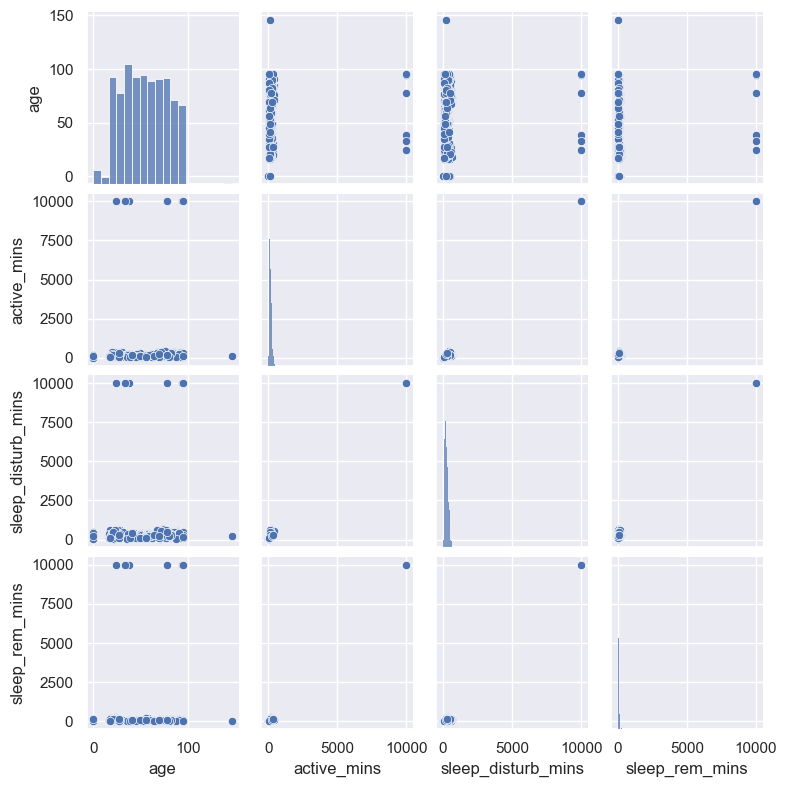

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
warnings.filterwarnings('ignore')

sns.set_theme()
sns.pairplot(dat[['age', 'active_mins', 'sleep_disturb_mins', 'sleep_rem_mins']], height = 2, aspect = 1);

I do want to point out that it's clear those "9999" values we saw in the table summaries above are giving us "scale" problems.  Notice how all of the sleep minute variables have all of their values and distributions far to the left side of each plot around the 200 range?  That's because we have those extreme outlier values way over on the right side of the graph near 10,000, but there's so few of them that they don't even show up in most cases.

Hang tight.  We're still in the exploratory and understanding phase so we'll deal with them soon in the {doc}`preprocessing` steps and you'll get to see the impacts of correcting this type of common issue.

Ok, that's it for now with what we want to look at for the numeric features.  Let's move on and run the same summary function over our categorical variables and see what we get.

<h4>Categorical</h4>

We start simply with categorical features in the same way as we did with the numeric ones, by calculating a few summary statistics.  Notice below how we get a completely different set of descriptive information however.  Again, this is because the operations you can perform with object, string, and character data types will be different than those of a numeric type.

In [58]:
# Print categorical summary stats
dat[['id','gender','country','study_begin','study_end']].describe()

,id,gender,country,study_begin,study_end
count,877,877,877,877,864
unique,875,2,4,1,3
top,89,F,Italy,4/3/2021,4/9/2023
freq,2,613,345,877,861


So what do we get with categorical summary statistics?

**Count** - The total number of non-null records in the variable <br>
**Unique** - The total unique count of values under each variable category <br>
**Top** - The most common value found in the feature, also known as the "mode" <br>
**Freq** - The total number of values observed for the most common value found in the "top" print out

Armed with these definitions and knowing what you know about our data and project, can you already see some issues we're going to need to deal with?  Hope so... but it's ok if not.  We'll get there together.  Since we only have a few features to cover let's walk through all of them one at a time.

Starting with `id`.  What can we see?  Here's a good way to identify that we have duplicates in our data since we have a total of 877 non-empty ids, but only 875 are unique.  So clearly we have two duplicate records in the data somewhere.  This is also reflected in the fact that we have one participant id (id = 89) as the most common with a frequency count of 2.  Recall that we said our unit of analysis for this data is expected to be one record per participant id, so this is clearly pointing to an issue.

How about `gender`?  877 total records, good so far.  Two unique values makes sense, and we can suppose if there are only two that it would be male and female, but we can check in a minute to be certain, but nothing unusual so far.  The most common value is "F", which I think it's safe to assume stands for female.  And female is the majority class of the gender variable with 70% of the two class split (613/877 = 70%).

`country` looks to make sense as well, assuming we were only expecting to see 4 countries in the dataset of course.  We would know right away we have a problem if we have less than expected, or more than expected or is possible given some constraint, as with there are only so many countries in the world, and any number beyond that limit wouldn't make sense.  Lastly Italy is the most common value, making up 39% of the total (345/877 = 39%).  We have no reason to believe this is out of line at this point.

Now for the dates - `study_begin` and `study_end`.  First off, these are actually date data types, but since we only have a few unique values there's no real reason to care that they're represented with the categorical features.  Notice how we only have 864 values for `study_end` though?  That should tip you off that we have some missing values since it's clearly less than the total number of records in the dataset of 877.  Also, see that `begin_date` only has one unqiue value.  This is both confirmation that everyone started on the same date and that we have no issues.  It's also telling us that this feature will serve no further purpose for us since there is no variability in that data.  On the other hand, `end_date` has three unique values so two things could be possible - 1) Not every participant ended the study on the same date, or 2) There are several dates incorrectly recorded in the data.  We'll have to ask our business partner which is the case.  We can see from the "top" count and frequency though that 98% of the values ended on 4/9/2023, so my money is on that any other date is a typo or incorrect in some way.  We'll see.

Ok, that's it for running through this summary of categorical variables in our data, but we can also print a list of every unique value for each feature if you really want to see what's contained for each.  This may not be practical if you have a high number of unique values, but in our case it won't be a problem since we have really low frequency counts.

See below.

In [60]:
cat_vars = ['gender','country','study_begin','study_end']
print(dat[cat_vars].apply(pd.unique))

gender                                         [F, M]
country                   [USA, Poland, Italy, Spain]
study_begin                                [4/3/2021]
study_end      [4/9/2023, nan, 4/12/2023, 10/13/2023]
dtype: object


Nice!  Everything makes sense and confirms what we learned from the summary counts above.  The only really issue we'll need to address shortly will be the multiple `study_end` dates.  Stay tuned.

````{margin}
```{note}
**Cardinality** refers to the "uniqueness" of a variable and how much variability is present.
```
````

The last topic I want to introduce here is a concept we touched on, but just briefly, and that is what's known as **cardinality**.  This refers to the "uniqueness" of a variable and how much variability is present.  For example, if all of the values contained under a feature are the same, then it has low cardinality.  If all of the values are distinct and different, then this feature would have high cardinality.

We saw that all of our numeric features have a wide range of unique values, and for `id`, `gender`, and `country` we have a good mix of values with no one value making up a disproportionately large amount of the values.  For both `study_begin` and `study_end` dates, we have just one value making up either 100%, or nearly 100% of the total values.  These would be refered to as static (if 0% variability), in that they do not change, and thus carry no information content towards describing a relationship with some target of interest.  Said another way, static variables that do not change at all are essentially worthless to any analysis, outside of simple header level meta data, because there are no differences and interactions to observe.

````{margin}
```{note}
**Information content** refers to the value of a variable or feature based on the amount of information it yields in describing or explaining a relationship with some target of interest.
```
````

We care about a few situations of uniqueness of features for a couple of reasons.  First, is what you're seeing what you expected?  If we know the study started on one date only, then we should see no variance.  This confirms what we know to be ture.  So the first concern is to measure what you see against what seems plausible and reasonable for the data under study.  Second, we want to consider the potential **information content** contained within a variable, i.e. how useful the feature may be for helping to describe a situation or another variable.  Statistical inference and machine learning are all about finding relationships and patterns between features by analyzing their interactions as values change, so if you have features that do not change at all, you can expect them to offer no value in your pursuit.  Get rid of them!

**<h3>Data Integrity</h3>**

Last up we'll cover a couple of well known data integrity issues that you'll always want to be on the lookout for.

<h4>Missing Values</h4>

The topic of missing values could fill the contents of a book by itself believe it or not.  There are several different kinds of "missing" values, and also several different mechanisms that create missing values which all have implications for the different ways we need to handle them.

At the end of the day, it's always a battle between removing the entire variable (column) with the missing values, removing any observation (row) entirely that has missing values, or _imputing_ (filling in) any missing values with a proxy value so we're are able to keep the observation and still use it in our analysis.

The main considerations with imputation are, 1) what methods are we going to use to do so, and 2) what percentage of imputed values are too many that render the variable too synthetic?  If you impute and fill in 90% of a column of data with approximated values, is it really going to tell you anything worthwhile?  As a general rule of thumb, you would probably be wise to remove any variable feature that has more than 50% of its values missing.  We'll address these considerations more in the next section.

Now, what about the types of missing values?

1. Missing Completely At Random (MCAR)

   MCAR assumes that all of the missing values have the same probability of being absent, and there's no systematic bias or pattern as to how the values are missing.  It is best safely thought of as
   unrealistic in the real-world.
   
3. Missing At Random (MAR)

   MAR indicate that the probability of the value being missing is somehow related to the value of another observed feature(s) in the dataset.  This type may or may not introduce bias into the system.

3. Missing Not At Random (MNAR)

   MNAR missing values are missing because they are systematically related to the unobserved data in some way, i.e. related to factors outside of our controls which are not measured.  This type of
   missing value will most likely introduce bias.

In [66]:
# Count NA's by feature
dat.isna().sum()

id                     0
gender                 0
age                    1
country                0
study_begin            0
study_end             13
active_mins            4
sleep_disturb_mins     6
sleep_rem_mins         9
dtype: int64

Not unusual or unexpected given our passes through the data already.  We have a several features with missing values we'll need to address.

This is another area we may want to talk to our business domain expert about.  They may be able to help us fill in the missing values or give us some insight as to why they're missing, but for now think about what types of missing values these might be.

The missing `age` value may just be an omission because it's only 1 person, or it might be MNAR because it could be related to something outside of what we can observe.  If there were more, it might be MAR due to some kind of relation between maybe gender at a prefence to not give their age, and so on.

One last consideration not applicable here, but will be when we cover time series under machine learning, is the situation of missing time periods.  It's quite common to see missing date records (rows) either due to omission, or the compression that happens in data storage when there is no value to record.  This will throw a wrench in the works for our time series algorithms that expect every single time period accounted for in our total range of dates.  This is known as _regular_ periodicity where the records are recorded at regular intervals, as opposed to irregular periodicity.  More to come on this topic later.

<h4>Duplicate Records</h4>

We've also touched on these quite a bit so far, so we'll leave most of the conversation until we get to addressing them in the next sections.  For now you see we've isolated just the two unique ids that have duplicate records we'll have to deal with.

In [70]:
# Find all of the duplicates by the id's identified above if you want to see all of them plus the originals
dat[dat['id'].isin([89,238])]

,id,gender,age,country,study_begin,study_end,active_mins,sleep_disturb_mins,sleep_rem_mins
87,89,F,53.0,Italy,4/3/2021,4/9/2023,141.0,186.6,107.1
88,89,F,53.0,Italy,4/3/2021,4/9/2023,141.0,186.6,107.1
237,238,M,0.0,Poland,4/3/2021,4/9/2023,2.0,2.0,2.0
238,238,M,0.0,Poland,4/3/2021,4/9/2023,2.0,2.0,2.0


**<h3>What Did We Learn?</h3>**

Ok, so that's it for now.  This is likely all I would do at this time for my initial pass through of the data (I'm intentionally deferring the use of graphs and plots for a future section, but know they are generally a big part of your EDA work and will be covered soon).  Coming up we will discuss how to fix all of these issues in the next section, and also start to introduce some basic plotting and graphing techinques you can use to explore the relationships in your data as well.

The last though I'd like to leave you with in this section is the notion of an automated Data Quality Report, or Profile Report.  Learning how to work through all of this manually is extremely valuable time well spent.  You'll be a much stronger analyst for it if you can learn to think through how to identify issues and think through the questions you want to ask of the data.  Having said all of that, you should know that there are plenty of libraries and tools that essentially do everything we've just done (and then some) automatically, depending on the platform you're using.

Don't be angry.  Remember, you're a better analyst now.

I personally find the value in doing it all manually like we've just done, but I certainly understand the appeal of a simple two lines of code or push of a button approach as well.  To each his or her own.  Use whatever suits your style.    

Below is an example using the python `ydata_profiling` library.  If you're learning to code, give it a spin and see what you think.  Otherwise, any solid analytics platform will allow you to get to this kind of information quickly and easily.

In [73]:
from ydata_profiling import ProfileReport

dqr = ProfileReport(dat, title = "Profiling Report")
dqr.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]